# 🎮 Jogo PCP 2 — FLAMENGO — Cockpit V2

Versão estratégica focada em VPL no longo prazo (15 rodadas).

**O que mudou vs V1:**
- Parâmetro `ESTRATEGIA` (conservador / balanceado / agressivo)
- Célula nova com **DRE + indicadores operacionais (espelhando o `IND_FLAMENGO.pdf`) + VPL**
- Histórico de resultados (calcula VPL acumulado)

**Fluxo:**
1. Setup
2. 📝 Estado inicial
3. 📝 OPs do prof
4. 📝 Preços
5. 📝 Histórico de resultados (rodadas anteriores)
6. Forecast HW próxima rodada
7. 📝 Estratégia + planejar
8. Tabela SOL_TRANSP
9. Tabela OP_FABRICAS
10. Resumo
11. 📊 **DRE + IND + VPL** (novo)
12. 📤 Gravar FLAMENGO.xlsm
13. Dashboard histórico

## 1. Setup

In [14]:
import sys, os, json
from pathlib import Path
import pandas as pd
BASE = Path('..').resolve()
sys.path.insert(0, str(BASE))
os.chdir(BASE)
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')
from src.config import Config
from src.io_xlsm import ler_instalacoes, escrever_planos_de_df
from src.planner_manual import planejar_rodada, forecast_proxima_rodada_via_hw
from src.indicadores import calcular_dre_e_ind, imprimir_painel
from src.dashboard import plot_historico
cfg = Config.load(BASE)
instalacoes = ler_instalacoes(BASE / 'rodadas' / 'FLAMENGO.xlsm')
print('OK — base:', BASE)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\lolil\\Downloads\\data\\parametros.json'

## 2. 📝 Estado inicial (do `ESTOQUES_FLAMENGO.pdf`)

In [ ]:
RODADA = 2

ESTOQUE_MP = {
    'MP1': 47.0,
    'MP2': 48.0,
    'MP3': 42.0,
}
ESTOQUE_PA_CD = {
    'CD1': {'PA1': 0, 'PA2': 0, 'PA3': 0},  # São Luís
    'CD2': {'PA1': 0, 'PA2': 0, 'PA3': 0},  # Santos
}
print(f'Rodada {RODADA} — estoque inicial OK')

Rodada 2 — estoque inicial OK


## 3. 📝 OPs do prof (do PDF da rodada)

⚠ Converta dias do jogo (Dia 6-10, etc.) para dias da rodada (1-5).

In [ ]:
OPS = [
    # PA1 R2 — dias jogo 6-10 → dias rodada 1-5
    {'cidade': 'Belém',                 'pa': 'PA1', 'qtd': 6009,  'dia_entrega': 5},
    {'cidade': 'Belo Horizonte',        'pa': 'PA1', 'qtd': 33385, 'dia_entrega': 3},
    {'cidade': 'Brasília',              'pa': 'PA1', 'qtd': 25595, 'dia_entrega': 3},
    {'cidade': 'Campinas',              'pa': 'PA1', 'qtd': 26708, 'dia_entrega': 2},
    {'cidade': 'Campo Grande',          'pa': 'PA1', 'qtd': 5119,  'dia_entrega': 3},
    {'cidade': 'Cuiabá',                'pa': 'PA1', 'qtd': 6143,  'dia_entrega': 3},
    {'cidade': 'Curitiba',              'pa': 'PA1', 'qtd': 22524, 'dia_entrega': 2},
    {'cidade': 'Fortaleza',             'pa': 'PA1', 'qtd': 20432, 'dia_entrega': 5},
    {'cidade': 'Goiânia',               'pa': 'PA1', 'qtd': 14333, 'dia_entrega': 3},
    {'cidade': 'João Pessoa',           'pa': 'PA1', 'qtd': 12019, 'dia_entrega': 4},
    {'cidade': 'Joinville',             'pa': 'PA1', 'qtd': 6143,  'dia_entrega': 2},
    {'cidade': 'Maceió',                'pa': 'PA1', 'qtd': 12019, 'dia_entrega': 4},
    {'cidade': 'Manaus',                'pa': 'PA1', 'qtd': 6009,  'dia_entrega': 5},
    {'cidade': 'Natal',                 'pa': 'PA1', 'qtd': 12019, 'dia_entrega': 5},
    {'cidade': 'Porto Alegre',          'pa': 'PA1', 'qtd': 22524, 'dia_entrega': 2},
    {'cidade': 'Recife',                'pa': 'PA1', 'qtd': 18028, 'dia_entrega': 4},
    {'cidade': 'Ribeirão Preto',        'pa': 'PA1', 'qtd': 22257, 'dia_entrega': 2},
    {'cidade': 'Rio de Janeiro',        'pa': 'PA1', 'qtd': 44513, 'dia_entrega': 3},
    {'cidade': 'Salvador',              'pa': 'PA1', 'qtd': 24037, 'dia_entrega': 4},
    {'cidade': 'Santos',                'pa': 'PA1', 'qtd': 22257, 'dia_entrega': 2},
    {'cidade': 'São Luís',              'pa': 'PA1', 'qtd': 6009,  'dia_entrega': 5},
    {'cidade': 'São Paulo',             'pa': 'PA1', 'qtd': 55642, 'dia_entrega': 2},
    {'cidade': 'Uberlândia',            'pa': 'PA1', 'qtd': 11128, 'dia_entrega': 3},
    {'cidade': 'Vitória',               'pa': 'PA1', 'qtd': 6677,  'dia_entrega': 3},
    {'cidade': 'Vitória da Conquista',  'pa': 'PA1', 'qtd': 3606,  'dia_entrega': 4},
]
print(f'{len(OPS)} OPs — total {sum(o["qtd"] for o in OPS):,} frascos')

25 OPs — total 445,135 frascos


## 4. 📝 Preços de mercado

In [ ]:
PRECOS = {
    'PA1': 64.00,
    'PA2': cfg.precos_referencia['PA2'],
    'PA3': cfg.precos_referencia['PA3'],
}
print('Preços:', PRECOS)

Preços: {'PA1': 64.0, 'PA2': 50, 'PA3': 25}


## 5. 📝 Histórico de resultados das rodadas anteriores

Cole os **resultados** (lucro/prejuízo) das rodadas anteriores em ordem.
Rodada 1 do DRE: -R$ 5.602.321 (incluindo set-up). Sem set-up, custo operacional ~R$ 1.128k.

In [ ]:
# Histórico — lucro (positivo) ou prejuízo (negativo) por rodada
# Inclui Rodada 1: -R$ 5.602.321 (set-up + operação sem receita)
HISTORICO_RESULTADOS = [
    -5_602_321.0,  # Rodada 1
]
print(f'Histórico até R{RODADA-1}: {len(HISTORICO_RESULTADOS)} rodada(s)')
print(f'Acumulado nominal: R$ {sum(HISTORICO_RESULTADOS):,.2f}')

Histórico até R1: 1 rodada(s)
Acumulado nominal: R$ -5,602,321.00


## 6. Forecast HW da próxima rodada (automático)

In [ ]:
forecast_next = forecast_proxima_rodada_via_hw(rodada_n_atual=RODADA, base_dir=BASE)
pa1_next = sum(v for (c, pa), v in forecast_next.items() if pa == 'PA1')
print(f'Forecast PA1 R{RODADA+1}: {pa1_next:,.0f} frascos (Brasil)')
print(f'FLAMENGO ~40% share: {pa1_next*0.4:,.0f} frascos')

Forecast PA1 R3: 464,053 frascos (Brasil)
FLAMENGO ~40% share: 185,621 frascos


## 7. 📝 Estratégia + Planejamento

- `'conservador'`: só caminhão/navio. Descarta OPs que precisam avião. **VPL máximo no longo prazo.**
- `'balanceado'` (padrão): caminhão padrão; avião só onde lead caminhão é inviável.
- `'agressivo'`: avião livre. Maximiza receita mas pesa em frete.

Para a **R2 com CDs zerados e foco em VPL longo prazo, recomendo `'conservador'`** —
aceitar perda agora pra acumular estoque com calma.

In [ ]:
ESTRATEGIA = 'agressivo'  # 'conservador' | 'balanceado' | 'agressivo'
BUFFER_PCT = 0          # quanto da previsão R+1 estocar nos CDs

resultado = planejar_rodada(
    rodada_n=RODADA,
    ops_rodada=OPS,
    forecast_proxima=forecast_next,
    estado_inicial_mp_ton=ESTOQUE_MP,
    estado_inicial_pa_cd=ESTOQUE_PA_CD,
    cfg=cfg,
    instalacoes=instalacoes,
    buffer_pct=BUFFER_PCT,
    estrategia=ESTRATEGIA,
)
df_sol_transp = resultado['df_sol_transp']
df_op_fabricas = resultado['df_op_fabricas']
resumo = resultado['resumo']
print(f'Plano: {len(df_sol_transp)} transportes')
print(f'Atendimento: {resumo["qtd_atendida"]:,}/{resumo["qtd_atendida"]+resumo["qtd_descartada"]:,} frascos')

Plano: 172 transportes
Atendimento: 267,080/445,135 frascos


## 8. 📋 SOL_TRANSP (DataFrame final)

In [ ]:
df_show = df_sol_transp.rename(columns={'Cidade_Destino': 'Cidade Destino'})
df_show

,Rodada,Origem,Cidade,Dia da Coleta,Modal,Tipo do Produto,Qtde,Destino,Cidade Destino
0,Rodada_2,Fábrica,Joinville,Dia 1,Avião,PA1,3333,CD,São Luís
1,Rodada_2,Fábrica,Joinville,Dia 1,Avião,PA1,3333,CD,São Luís
2,Rodada_2,Fábrica,Joinville,Dia 1,Avião,PA1,3333,CD,São Luís
3,Rodada_2,Fábrica,Joinville,Dia 1,Avião,PA1,3333,CD,São Luís
4,Rodada_2,Fábrica,Joinville,Dia 1,Avião,PA1,3333,CD,São Luís
...,...,...,...,...,...,...,...,...,...
167,Rodada_2,CD,São Luís,Dia 2,Avião,PA1,3333,Varejista,Vitória
168,Rodada_2,CD,São Luís,Dia 2,Avião,PA1,3333,Varejista,Vitória
169,Rodada_2,CD,São Luís,Dia 2,Avião,PA1,11,Varejista,Vitória
170,Rodada_2,CD,São Luís,Dia 3,Avião,PA1,3333,Varejista,Vitória da Conquista


## 9. 📋 OP_FABRICAS

In [ ]:
df_op_fabricas

,Dia,PA1,PA2,PA3
0,Dia 1,146893,0,0
1,Dia 2,69709,0,0
2,Dia 3,50478,0,0
3,Dia 4,0,0,0
4,Dia 5,0,0,0


## 10. Resumo operacional

In [ ]:
print('━' * 60)
print(f'  RODADA {RODADA} — Estratégia: {ESTRATEGIA}')
print('━' * 60)
print(f'OPs atendidas: {resumo["ops_atendidas"]}/{resumo["ops_total"]}')
print(f'Qtd atendida:  {resumo["qtd_atendida"]:,} frascos ({resumo["taxa_atendimento_pct"]:.1f}%)')
print(f'Qtd descartada: {resumo["qtd_descartada"]:,}')
print()
print('Produção por PA:', resumo['producao_total_por_pa'])
print('Buffer R+1:    ', resumo['buffer_acumulado_pa'])
print()
print('MP a comprar:')
for mp, ton in resumo['mp_a_comprar_ton'].items():
    if ton > 0.1:
        print(f'  {mp}: {ton:.1f} ton')
print()
print('Min-máq usados/dia (cap=10080):')
for d, m in enumerate(resumo['minutos_usados_por_dia'], 1):
    print(f'  Dia {d}: {m:,} ({m/10080*100:.1f}%)')
if resumo['descartadas']:
    print()
    print('OPs descartadas:')
    for d in resumo['descartadas']:
        print(f'  ❌ {d.get("cidade","?"):<22} qtd={d.get("qtd",0):>6,} dia={d.get("dia_entrega","?")}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RODADA 2 — Estratégia: agressivo
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
OPs atendidas: 18/25
Qtd atendida:  267,080 frascos (60.0%)
Qtd descartada: 178,055

Produção por PA: {'PA1': 267080, 'PA2': 0, 'PA3': 0}
Buffer R+1:     {'PA1': 0, 'PA2': 0, 'PA3': 0}

MP a comprar:

Min-máq usados/dia (cap=10080):
  Dia 1: 9,797 (97.2%)
  Dia 2: 4,650 (46.1%)
  Dia 3: 3,368 (33.4%)
  Dia 4: 0 (0.0%)
  Dia 5: 0 (0.0%)

OPs descartadas:
  ❌ Campinas               qtd=26,708 dia=2
  ❌ Curitiba               qtd=22,524 dia=2
  ❌ Joinville              qtd= 6,143 dia=2
  ❌ Porto Alegre           qtd=22,524 dia=2
  ❌ Ribeirão Preto         qtd=22,257 dia=2
  ❌ Santos                 qtd=22,257 dia=2
  ❌ São Paulo              qtd=55,642 dia=2


## 11. 📊 DRE + IND_FLAMENGO + VPL

Painel financeiro e operacional **espelhando os relatórios do prof**:
- **DRE**: receita - todos os custos detalhados (parcelas, MP, frete, carregamento, etc.)
- **IND**: utilização da fábrica, distribuição modal, custo/ton
- **VPL**: valor presente líquido descontado (foco no longo prazo)

In [ ]:
# Calcula qtd atendida por PA a partir das tarefas finalizadas
qtd_atendida_por_pa = {'PA1': 0, 'PA2': 0, 'PA3': 0}
# Soma das OPs que foram efetivamente alocadas (não descartadas)
ops_descartadas_set = {(d.get('cidade'), d.get('pa'), d.get('dia_entrega'))
                        for d in resumo['descartadas']}
for o in OPS:
    k = (o['cidade'], o['pa'], o['dia_entrega'])
    if k not in ops_descartadas_set:
        qtd_atendida_por_pa[o['pa']] += o['qtd']

# Estimativa de estoque final nos CDs = estoque inicial + buffer produzido
estoque_pa_final = {
    cd: {pa: ESTOQUE_PA_CD[cd][pa] + resumo['buffer_acumulado_pa'][pa] // 2
         for pa in ('PA1','PA2','PA3')}
    for cd in ESTOQUE_PA_CD
}
# Estimativa de estoque MP final = inicial + comprado - consumido
estoque_mp_final = {
    mp: max(0, ESTOQUE_MP[mp]
             + resumo['mp_a_comprar_ton'][mp]
             - sum(resumo['producao_total_por_pa'][pa] * cfg.BoM[pa][mp] / 1_000_000
                   for pa in ('PA1','PA2','PA3')))
    for mp in ('MP1','MP2','MP3')
}

indicadores = calcular_dre_e_ind(
    rodada_n=RODADA,
    df_sol_transp=df_sol_transp,
    df_op_fabricas=df_op_fabricas,
    qtd_atendida_por_pa=qtd_atendida_por_pa,
    precos=PRECOS,
    estoque_pa_final=estoque_pa_final,
    estoque_mp_final=estoque_mp_final,
    cfg=cfg,
    instalacoes=instalacoes,
    historico_resultados=HISTORICO_RESULTADOS,
)
imprimir_painel(indicadores)

  PAINEL — RODADA 2

💰 RECEITA
  PA1: R$  17,093,120.00
  TOTAL Receita:  R$  17,093,120.00

💸 CUSTOS
  Estruturais (fixos):
    Parcelas terrenos:     R$   506,968.00
    Parcelas máquinas:     R$   415,567.00
    Manut fábricas:        R$     1,313.00
    Salário operários:     R$       450.00
    Custo produção:        R$   172,086.00
    Manut CDs:             R$    26,683.00
  Variáveis:
    MP comprada:           R$         0.00
    Frete MP:              R$         0.00
    Frete PA:              R$ 6,427,821.87
    Carreg MP:             R$    23,412.51
    Carreg PA:             R$         0.00
  CUSTO TOTAL:             R$ 7,579,795.38

  RESULTADO DA RODADA:     R$ 9,513,324.62  ✅

🏭 FÁBRICA F1
  Cap HH semanal:    840
  Utilização:        35.3% (ociosidade 64.7%)
  Custo médio/frasco: R$ 28.38

🚛 TRANSPORTE
  Viagens: {'Caminhão': 0, 'Navio': 0, 'Avião': 172}
  Ton/modal: {'Caminhão': 0.0, 'Navio': 0.0, 'Avião': 160.25}
  Distribuição (%): {'Caminhão': 0.0, 'Navio': 0.0, 'A

## 12. 📤 Gravar `FLAMENGO.xlsm` (pronto para entregar)

Escreve as duas abas preservando VBA, fórmulas e demais abas.

In [ ]:
flamengo_path = BASE / 'rodadas' / 'FLAMENGO.xlsm'
n = escrever_planos_de_df(flamengo_path, df_sol_transp, df_op_fabricas, rodada_n=RODADA)
print(f'✅ FLAMENGO.xlsm atualizado: {n} linhas em SOL_TRANSP da Rodada_{RODADA}')
print(f'   {flamengo_path}')
print('   VBA, fórmulas e demais abas preservadas. Pronto pra entregar.')

✅ FLAMENGO.xlsm atualizado: 172 linhas em SOL_TRANSP da Rodada_2
   C:\Users\lolil\Downloads\Jogo PCP 2 (a vinganca)\rodadas\FLAMENGO.xlsm
   VBA, fórmulas e demais abas preservadas. Pronto pra entregar.


## 13. Dashboard histórico (rodadas anteriores)

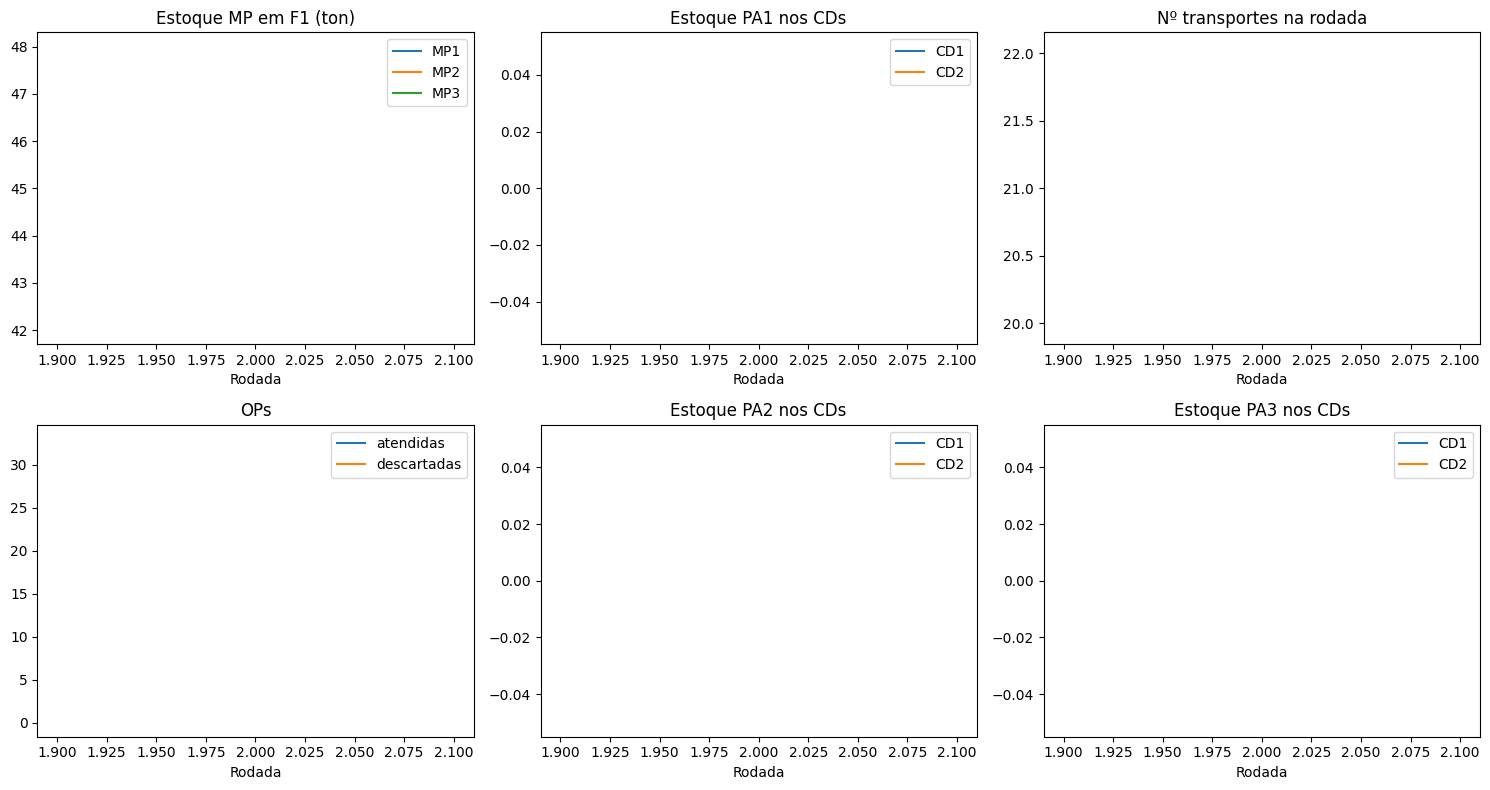

 rodada  transportes  ops_atendidas  ops_descartadas  estoque_mp1_F1  estoque_mp2_F1  estoque_mp3_F1  estoque_pa1_cd1  estoque_pa1_cd2  estoque_pa2_cd1  estoque_pa2_cd2  estoque_pa3_cd1  estoque_pa3_cd2
      2           21              0               33            47.0            48.0            42.0                0                0                0                0                0                0


In [ ]:
plot_historico(BASE / 'estado')